In [2]:
from herbie import Herbie, FastHerbie
import pandas as pd, numpy as np
import xarray as xr
import dask
import matplotlib.pyplot as plt
import cartopy.crs as ccrs, cartopy.feature as cfeature

In [3]:
nullds = xr.open_dataset('nullhrrr.nc') # run first
nullds

sh: 1: getfattr: not found


<xarray.Dataset> Size: 2GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2021-10-13 ... 2021-1...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B ...
    atmosphere         float64 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    heightAboveGround  float64 8B ...
    surface            float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    ltng               (valid_time, y, x) float32 373MB ...
    t2m                (valid_time, y, x) float32 373MB ...
    r2                 (valid_time, y, x) float32 373MB ...
    prate              (valid_time, y, x) float32 373MB ...
    tcc                (valid_time, y, x) float32 373MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-25T16:20 GRIB to CDM+CF via cfgrib-0.9.1...

In [4]:
incidentds = xr.open_dataset('hrrr.nc') # run first
incidentds

sh: 1: getfattr: not found


<xarray.Dataset> Size: 2GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2021-10-10 ... 2021-1...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B ...
    atmosphere         float64 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    heightAboveGround  float64 8B ...
    surface            float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    ltng               (valid_time, y, x) float32 373MB ...
    t2m                (valid_time, y, x) float32 373MB ...
    r2                 (valid_time, y, x) float32 373MB ...
    prate              (valid_time, y, x) float32 373MB ...
    tcc                (valid_time, y, x) float32 373MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-25T16:06 GRIB to CDM+CF via cfgrib-0.9.1...

In [5]:
nullds = nullds.sortby('valid_time')
nullds

<xarray.Dataset> Size: 2GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2021-10-13 ... 2021-1...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B ...
    atmosphere         float64 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    heightAboveGround  float64 8B ...
    surface            float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    ltng               (valid_time, y, x) float32 373MB ...
    t2m                (valid_time, y, x) float32 373MB ...
    r2                 (valid_time, y, x) float32 373MB ...
    prate              (valid_time, y, x) float32 373MB ...
    tcc                (valid_time, y, x) float32 373MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-25T16:20 GRIB to CDM+CF via cfgrib-0.9.1...

In [6]:
incidentds = incidentds.sortby('valid_time')
incidentds

<xarray.Dataset> Size: 2GB
Dimensions:            (valid_time: 49, y: 1059, x: 1799)
Coordinates:
  * valid_time         (valid_time) datetime64[ns] 392B 2021-10-10 ... 2021-1...
    time               datetime64[ns] 8B ...
    step               (valid_time) timedelta64[ns] 392B ...
    atmosphere         float64 8B ...
    latitude           (y, x) float64 15MB ...
    longitude          (y, x) float64 15MB ...
    heightAboveGround  float64 8B ...
    surface            float64 8B ...
Dimensions without coordinates: y, x
Data variables:
    ltng               (valid_time, y, x) float32 373MB ...
    t2m                (valid_time, y, x) float32 373MB ...
    r2                 (valid_time, y, x) float32 373MB ...
    prate              (valid_time, y, x) float32 373MB ...
    tcc                (valid_time, y, x) float32 373MB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-03-25T16:06 GRIB to CDM+CF via cfgrib-0.9.1...

(array([24359018.,  4889939.,  3107661.,  2342049.,  1796975.,  1789105.,
         1880509.,  2183626.,  2775664., 48227363.]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

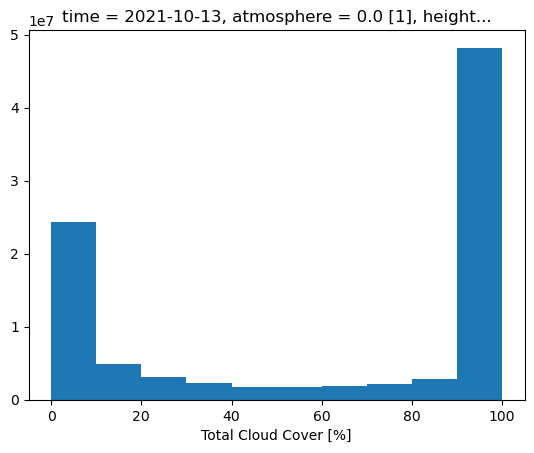

In [18]:
nullds['tcc'].plot()

(array([33594861.,  5070120.,  3152976.,  2369837.,  1813971.,  1722181.,
         1773715.,  2019119.,  2585785., 39249344.]),
 array([  0.,  10.,  20.,  30.,  40.,  50.,  60.,  70.,  80.,  90., 100.]),
 <BarContainer object of 10 artists>)

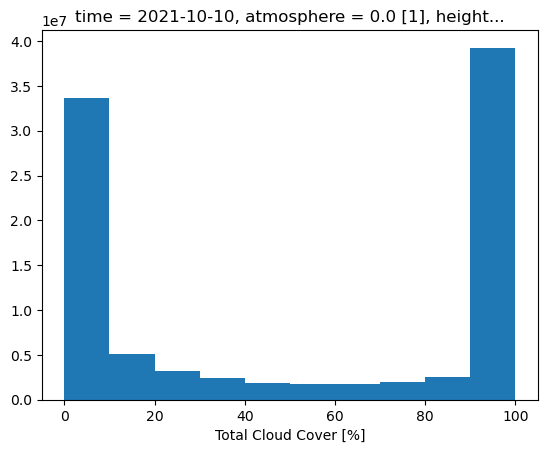

In [20]:
incidentds['tcc'].plot()

In [34]:
nullt2m = (nullds['t2m'] - 273.15) * 9/5 +32 # Convert Kelvin to Fahrenheit
incidentt2m = (incidentds['t2m'] - 273.15) * 9/5 +32 # Convert Kelvin to Fahrenheit

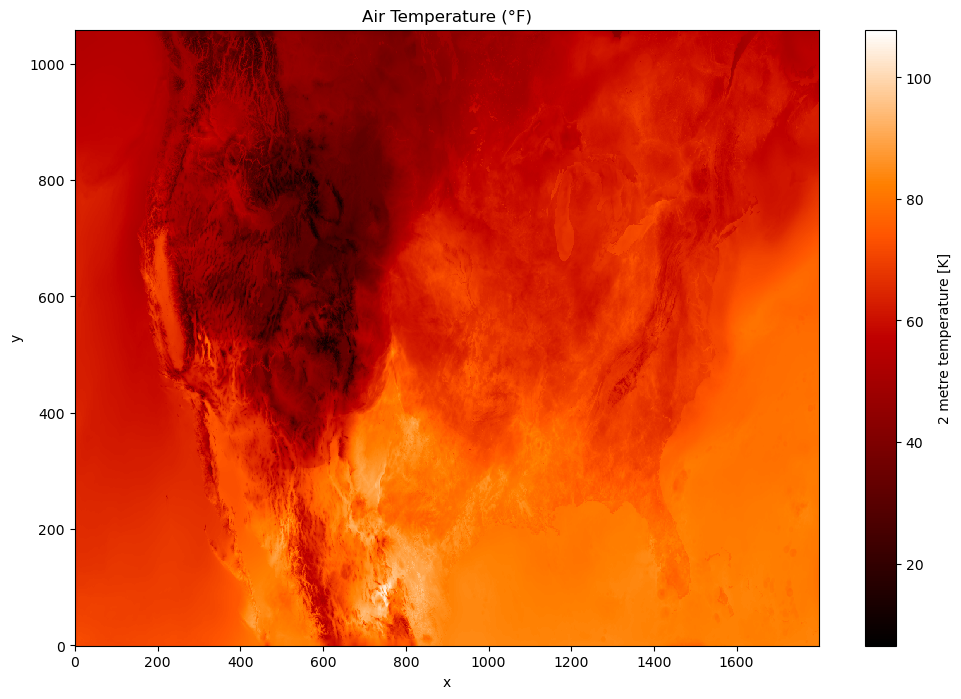

In [40]:
nullt2m.isel(valid_time=0).plot(figsize=(12, 8), cmap="gist_heat") #Change cmap for color
plt.title("Air Temperature (°F)")
plt.show()

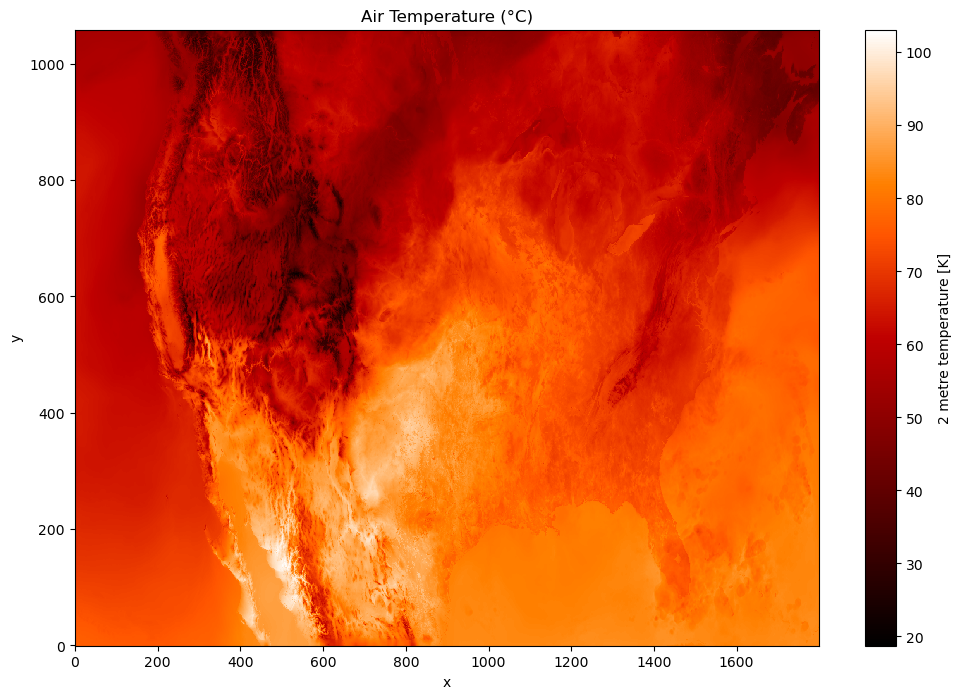

In [36]:
incidentt2m.isel(valid_time=0).plot(figsize=(12, 8), cmap="gist_heat")
plt.title("Air Temperature (°C)")
plt.show()